# **2. Regresión polinomial**

Temas selectos de aprendizaje de máquina \
Ana Luisa Llamas Martinez

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from ISLP import load_data
from ISLP.models import ModelSpec as MS, poly, summarize


## 2.4.1 Carga y exploración inicial

In [3]:
wage = load_data('Wage')
wage.shape

(3000, 11)

In [6]:
wage[[ 'age', 'wage']].describe()

,age,wage
count,3000.000000,3000.000000
mean,42.414667,111.703608
std,11.542406,41.728595
min,18.000000,20.085537
25%,33.750000,85.383940
50%,42.000000,104.921507
75%,51.000000,128.680488
max,80.000000,318.342430


## 2.4.2 Relación entre edad y salario

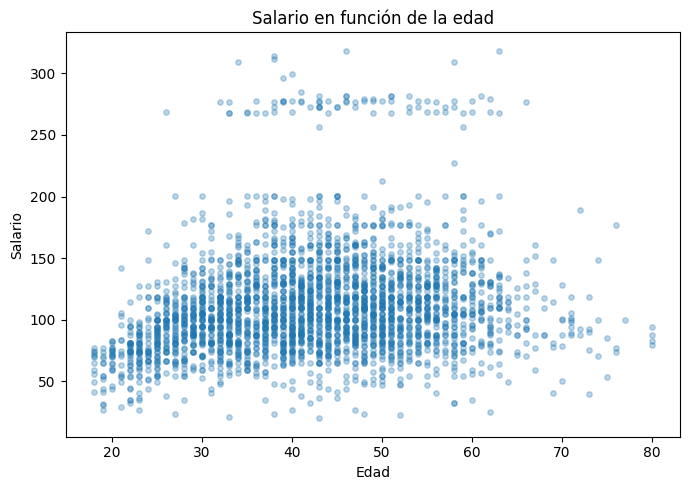

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(wage[ 'age'], wage['wage'], alpha=0.3, s=15)
plt.xlabel('Edad')
plt.ylabel('Salario')
plt.title('Salario en función de la edad')
plt.tight_layout()
plt.show()

## 2.6 Ajuste de un polinomio de grado 4

In [11]:
design_g4 = MS([poly('age', degree=4)])
x_g4 = design_g4.fit_transform(wage)
y = wage['wage']

modelo_g4 = sm.OLS(y, x_g4).fit()
summarize(modelo_g4)

,coef,std err,t,P>|t|
intercept,111.7036,0.729,153.283,0.000
"poly(age, degree=4)[0]",447.0679,39.915,11.201,0.000
"poly(age, degree=4)[1]",-478.3158,39.915,-11.983,0.000
"poly(age, degree=4)[2]",125.5217,39.915,3.145,0.002
"poly(age, degree=4)[3]",-77.9112,39.915,-1.952,0.051


## 2.7 Curva ajustada

In [18]:
age_grid = np.linspace(wage['age'].min(), wage['age'].max(), 200)

datos_pred = pd.DataFrame({'age': age_grid})

X_pred = design_g4.transform(datos_pred)
prediccion = modelo_g4.get_prediction(X_pred)

#95%
resumen_pred = prediccion.summary_frame(alpha=0.05)
resumen_pred.head()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,51.931450,5.298268,41.542837,62.320064,-27.018198,130.881099
1,54.031077,4.992907,44.241202,63.820952,-24.842019,132.904173
2,56.081359,4.702471,46.860958,65.301760,-22.723079,134.885797
3,58.083102,4.426735,49.403354,66.762851,-20.659908,136.826113
4,60.037106,4.165482,51.869611,68.204602,-18.651086,138.725299


In [28]:
resumen_pred

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,51.931450,5.298268,41.542837,62.320064,-27.018198,130.881099
1,54.031077,4.992907,44.241202,63.820952,-24.842019,132.904173
2,56.081359,4.702471,46.860958,65.301760,-22.723079,134.885797
3,58.083102,4.426735,49.403354,66.762851,-20.659908,136.826113
4,60.037106,4.165482,51.869611,68.204602,-18.651086,138.725299
...,...,...,...,...,...,...
195,86.091928,11.475773,63.590733,108.593123,4.658351,167.525505
196,85.006022,11.984561,61.507217,108.504828,3.291167,166.720877
197,83.890980,12.512895,59.356241,108.425719,1.872219,165.909741
198,82.746194,13.061134,57.136492,108.355896,0.399485,165.092903


## 2.7.1 Curva e intervalo de confianza

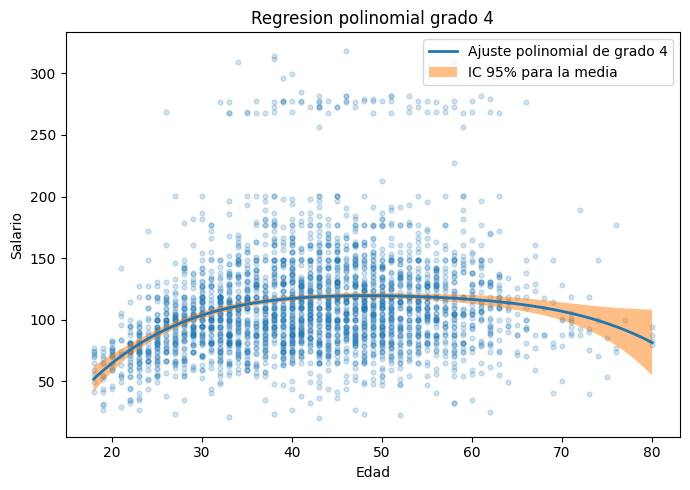

In [22]:
plt.figure(figsize=(7,5))
plt.scatter(wage['age'], wage['wage'], alpha=0.2, s=12)
plt.plot(age_grid, resumen_pred['mean'], lw=2, label = 'Ajuste polinomial de grado 4')
plt.fill_between(age_grid, resumen_pred['mean_ci_lower'],
                 resumen_pred['mean_ci_upper'],
                 alpha=0.5, label = 'IC 95% para la media')

plt.xlabel('Edad')
plt.ylabel('Salario')
plt.title('Regresion polinomial grado 4')

plt.legend()
plt.tight_layout()
plt.show()

## 2.8.3 Comparación gráfica

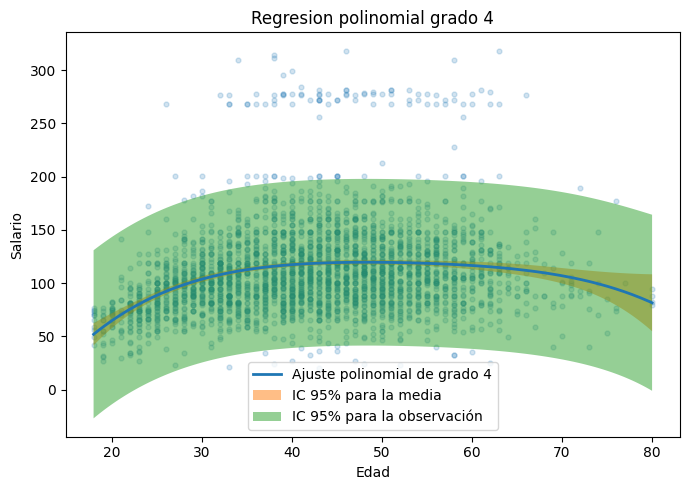

In [25]:

plt.figure(figsize=(7,5))
plt.scatter(wage['age'], wage['wage'], alpha=0.2, s=12)
plt.plot(age_grid, resumen_pred['mean'], lw=2, label = 'Ajuste polinomial de grado 4')

plt.fill_between(age_grid, resumen_pred['mean_ci_lower'],
                 resumen_pred['mean_ci_upper'],
                 alpha=0.5, label = 'IC 95% para la media')

plt.fill_between(age_grid, resumen_pred['obs_ci_lower'],
                 resumen_pred['obs_ci_upper'],
                 alpha=0.5, label = 'IC 95% para la observación')

plt.xlabel('Edad')
plt.ylabel('Salario')
plt.title('Regresion polinomial grado 4')

plt.legend()
plt.tight_layout()
plt.show()

## 2.9 ¿Qué cambia al aumentar el grado?

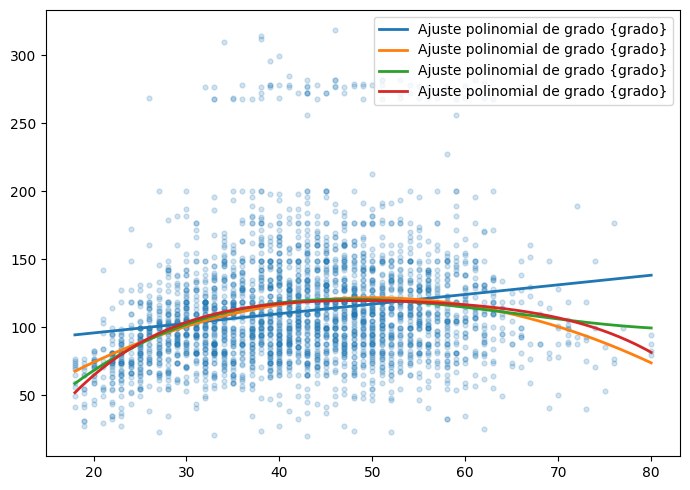

In [36]:
#ejercicio

Predicciones = []

plt.figure(figsize=(7,5))
plt.scatter(wage['age'], wage['wage'], alpha=0.2, s=12)

for i in range(1,5,1):
    grado = i
    design_gi = MS([poly('age', degree=i)])
    x_gi = design_gi.fit_transform(wage)
    y = wage['wage']

    modelo_gi = sm.OLS(y, x_gi).fit()

    Xi_pred = design_gi.transform(datos_pred)
    prediccioni = modelo_gi.get_prediction(Xi_pred)

    resumen_predi = prediccioni.summary_frame(alpha=0.05)

    plt.plot(age_grid, resumen_predi['mean'], lw=2, label = 'Ajuste polinomial de grado {grado}')

plt.legend()
plt.tight_layout()
plt.show()


## 2.10.1 Enfoque clásico: comparación de modelos anidados

In [37]:
modelos = {}

for d in range(1,6):
    design_d = MS([poly('age', degree = d)])
    X_d = design_d.fit_transform(wage)
    modelos[d] = sm.OLS(wage['wage'], X_d).fit()

tabla_anova = sm.stats.anova_lm(
    modelos[1],
    modelos[2],
    modelos[3],
    modelos[4],
    modelos[5]
)

tabla_anova

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2998.0,5.022216e+06,0.0,NaN,NaN,NaN
1,2997.0,4.793430e+06,1.0,228786.010128,143.593107,2.363850e-32
2,2996.0,4.777674e+06,1.0,15755.693664,9.888756,1.679202e-03
3,2995.0,4.771604e+06,1.0,6070.152124,3.809813,5.104620e-02
4,2994.0,4.770322e+06,1.0,1282.563017,0.804976,3.696820e-01


## 2.10.3 Implementación

In [89]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = wage[['age']].values
y_arr = wage['wage'].values

kf = KFold(
    n_splits=10,
    shuffle = True,
    random_state= 42
)

grados = range(1,11)

ecm_promedio = []

for d in grados:
    errores_folds = []
    transformador_poly = PolynomialFeatures(degree = 4, include_bias = False)
    for idx_train, idx_test in kf.split(X):
        X_train_poly = transformador_poly.fit_transform(X[idx_train])
        X_test_poly = transformador_poly.fit_transform(X[idx_test])
        modelo_cv = LinearRegression().fit(X_train_poly, y_arr[idx_train])
        pred = modelo_cv.predict(X_test_poly)
        errores_folds.append(mean_squared_error(y_arr[idx_test], pred))

    ecm_promedio.append(np.mean(errores_folds))

d_optimo = list(grados)[int(np.argmin(ecm_promedio))]

print(f'Grado optimo segun validacion cruzada: {d_optimo}')

Grado optimo segun validacion cruzada: 1


## 2.10.4 Error de validación cruzada

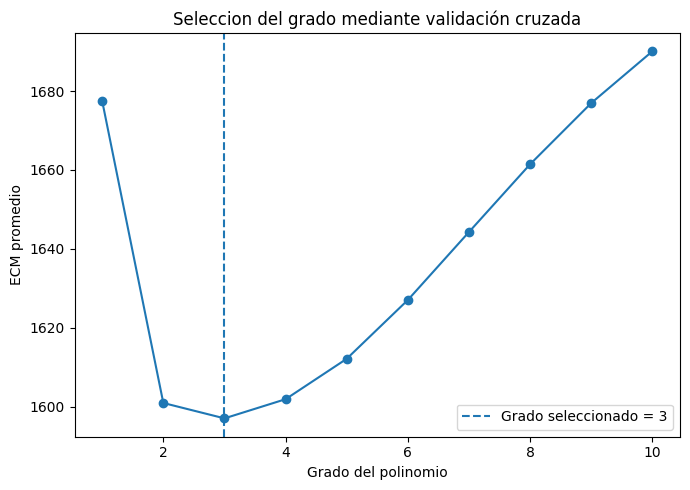

In [46]:
plt.figure(figsize = (7,5))

plt.plot(list(grados), ecm_promedio, marker = 'o')
plt.axvline(d_optimo, linestyle = '--', label = f'Grado seleccionado = {d_optimo}')

plt.xlabel('Grado del polinomio')
plt.ylabel('ECM promedio')
plt.title('Seleccion del grado mediante validación cruzada')

plt.legend()
plt.tight_layout()
plt.show()

## 2.11.2 Construcción de la variable respuesta

In [47]:
wage['salario_alto'] = (wage['wage']>250).astype(int)

wage['salario_alto'].value_counts()

salario_alto
0    2921
1      79
Name: count, dtype: int64

## 2.11.4 Construcción de la base polinomial

In [48]:
grado = 4
design_logit = MS([poly('age', degree = grado)])
design_logit = design_logit.fit(wage)
X_logit = design_logit.transform(wage)
y_logit = wage['salario_alto']

## 2.11.5 Ajuste de la regresión logística polinomial

In [49]:
model_logit = sm.GLM(y_logit, X_logit, family=sm.families.Binomial()).fit()

summarize(model_logit)

,coef,std err,z,P>|z|
intercept,-4.3012,0.345,-12.457,0.000
"poly(age, degree=4)[0]",71.9642,26.133,2.754,0.006
"poly(age, degree=4)[1]",-85.7729,35.929,-2.387,0.017
"poly(age, degree=4)[2]",34.1626,19.697,1.734,0.083
"poly(age, degree=4)[3]",-47.4008,24.105,-1.966,0.049


## 2.11.6 Predicciones sobre una grilla de edades

In [51]:
age_grid = np.linspace(wage['age'].min(), wage['age'].max(), 200)

datos_pred_logit = pd.DataFrame({'age': age_grid})

X_pred_logit = design_logit.transform(datos_pred_logit)
predict_logit = model_logit.get_prediction(X_pred_logit)
resumen_logit = predict_logit.summary_frame(alpha = 0.05)
resumen_logit.head()


,mean,mean_se,mean_ci_lower,mean_ci_upper
0,9.826349e-09,6.037272e-08,5.789509e-14,0.001665
1,1.900428e-08,1.113108e-07,1.964454e-13,0.001835
2,3.598553e-08,2.008033e-07,6.402190e-13,0.002019
3,6.674401e-08,3.545879e-07,2.005727e-12,0.002216
4,1.213091e-07,6.131647e-07,6.045581e-12,0.002428


## 2.11.7 Probabilidad de tener un salario alto

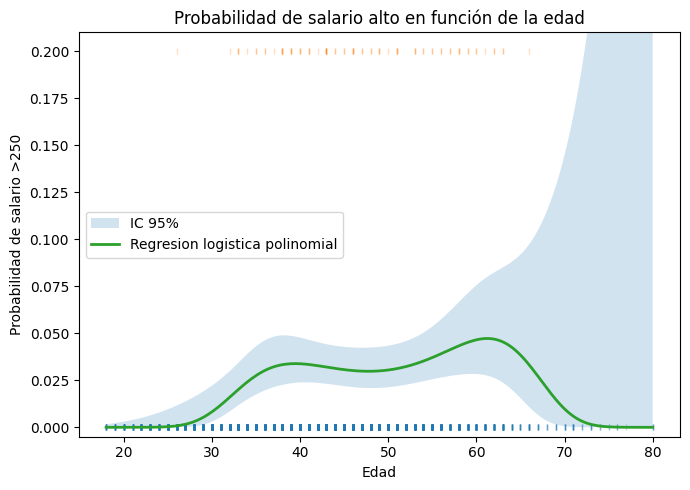

In [54]:
prob = resumen_logit['mean']

ic_lower = resumen_logit['mean_ci_lower']
ic_upper = resumen_logit['mean_ci_upper']

plt.figure(figsize=(7,5))

mask_bajo = wage['salario_alto']==0
plt.plot(wage.loc[mask_bajo, 'age'],
         np.zeros(mask_bajo.sum()),
         '|', alpha = 0.25, markersize = 5)

mask_alto = wage['salario_alto']==1
plt.plot(wage.loc[mask_alto, 'age'],
         np.repeat(0.20, mask_alto.sum()),
         '|', alpha = 0.25, markersize = 5)

plt.fill_between(age_grid, ic_lower, ic_upper, alpha = 0.20, label = 'IC 95%')

plt.plot(age_grid, prob, linewidth=2, label = 'Regresion logistica polinomial')

plt.xlabel('Edad')
plt.ylabel('Probabilidad de salario >250')
plt.title('Probabilidad de salario alto en función de la edad')

plt.ylim(-0.005, 0.21)
plt.legend()
plt.tight_layout()
plt.show()

## 2.13 Ejercicios de la práctica

**2.13.1** Selección del grado mediante AIC

Ajusten, para d= 1, 2, ..., 8, el modelo $MS([poly('age', degree=d)])$ y obtengan el AIC de cada modelo mediante $modelo.aic$.

Text(0.5, 1.0, 'd vs AIC')

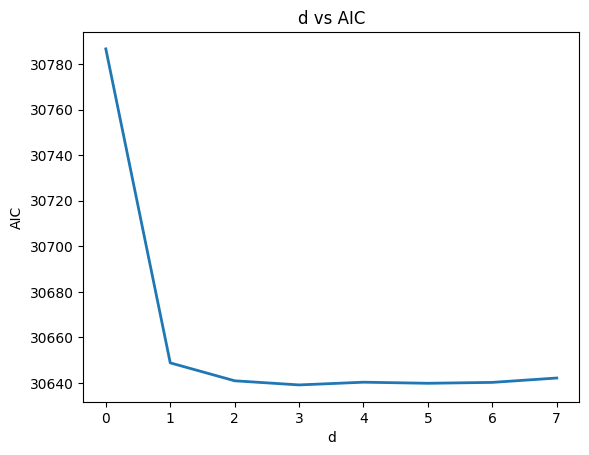

In [61]:
aic_arr = []
grados = range(1,9,1)
for i in grados:
    grado = i
    design_gi = MS([poly('age', degree=i)])
    x_gi = design_gi.fit_transform(wage)
    y = wage['wage']

    modelo_gi = sm.OLS(y, x_gi).fit()
    aic = modelo_gi.aic
    aic_arr.append(aic)
    

plt.plot(aic_arr, linewidth=2, label = 'aic vs d')

plt.xlabel('d')
plt.ylabel('AIC')
plt.title('d vs AIC')

In [62]:
list(grados)[int(np.argmin(aic_arr))]

4

1) ¿Qué grado minimiza el AIC?\
    **R:** 3
2) ¿Coincide con el grado sugerido por la comparación de modelos anidados?\
    **R:** Sí.
3) ¿Coincide con el obtenido mediante validación cruzada?\
    **R:** Sí.
4) Expliquen brevemente por qué los tres criterios no tienen que producir necesariamente la misma respuesta.\
    **R**: Sus enfoques son diferentes. ANOVA es mediante inferencias, Kfolds es por predictivo y AIC por complejidad.

**2.13.2** Otro predictor

Repitan el análisis utilizando year en lugar de age. 

Ajusten modelos polinomiales de distintos grados y construyan una gráfica que permita comparar los ajustes.

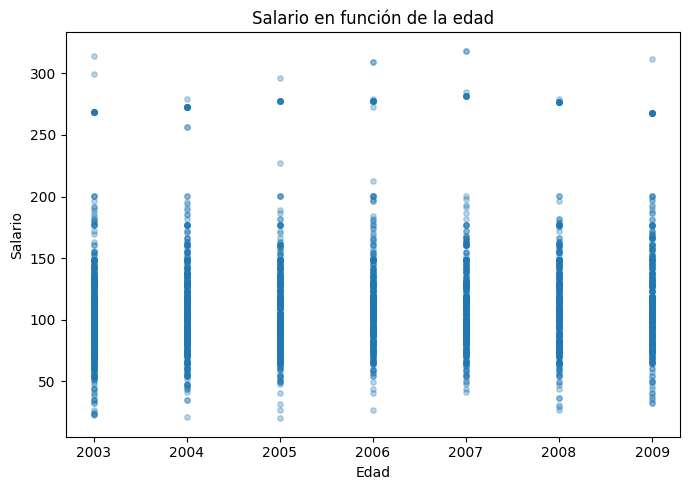

In [70]:
plt.figure(figsize=(7,5))
plt.scatter(wage[ 'year'], wage['wage'], alpha=0.3, s=15)
plt.xlabel('Edad')
plt.ylabel('Salario')
plt.title('Salario en función de la edad')
plt.tight_layout()
plt.show()

In [74]:
year_grid = np.linspace(wage['year'].min(), wage['year'].max(), 200)

datos_pred2 = pd.DataFrame({'year': year_grid})

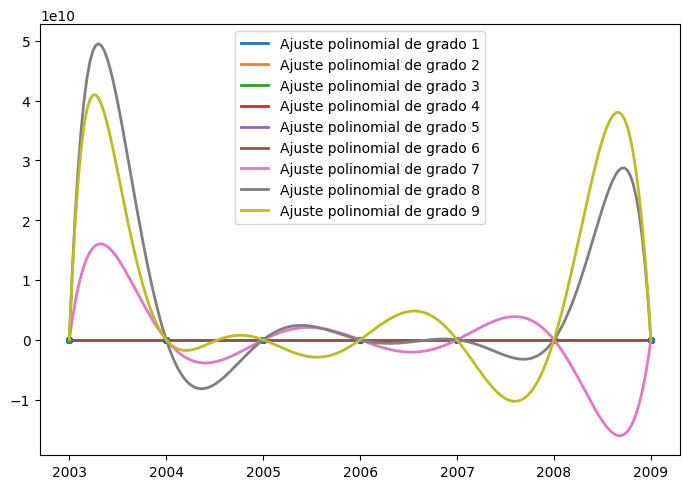

In [87]:
plt.figure(figsize=(7,5))
plt.scatter(wage['year'], wage['wage'], alpha=0.2, s=12)

for i in range(1,10,1):
    grado = i
    design_gi = MS([poly('year', degree=i)])
    x_gi = design_gi.fit_transform(wage)
    y = wage['wage']

    modelo_gi = sm.OLS(y, x_gi).fit()

    Xi_pred = design_gi.transform(datos_pred2)
    prediccioni = modelo_gi.get_prediction(Xi_pred)

    resumen_predi = prediccioni.summary_frame(alpha=0.05)

    plt.plot(year_grid, resumen_predi['mean'], lw=2, label = f'Ajuste polinomial de grado {grado}')

plt.legend()
plt.tight_layout()
plt.show()

In [77]:
modelos = {}

for d in range(1,6):
    design_d = MS([poly('year', degree = d)])
    X_d = design_d.fit_transform(wage)
    modelos[d] = sm.OLS(wage['wage'], X_d).fit()

tabla_anova = sm.stats.anova_lm(
    modelos[1],
    modelos[2],
    modelos[3],
    modelos[4],
    modelos[5]
)

tabla_anova

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2998.0,5.199651e+06,0.0,NaN,NaN,NaN
1,2997.0,5.198366e+06,1.0,1285.420349,0.740727,0.389497
2,2996.0,5.196868e+06,1.0,1497.701599,0.863055,0.352960
3,2995.0,5.196868e+06,1.0,0.226485,0.000131,0.990886
4,2994.0,5.195636e+06,1.0,1232.318293,0.710127,0.399469


In [79]:
aic_arr = []
grados = range(1,9,1)
for i in grados:
    grado = i
    design_gi = MS([poly('year', degree=i)])
    x_gi = design_gi.fit_transform(wage)
    y = wage['wage']

    modelo_gi = sm.OLS(y, x_gi).fit()
    aic = modelo_gi.aic
    aic_arr.append(aic)

list(grados)[int(np.argmin(aic_arr))]

1

¿Encuentran evidencia de una relación no lineal igual de fuerte que la observada para age? Justifiquen su respuesta utilizando tanto la gráfica como los resultados de los modelos.

**R:** No. En este caso, tanto por el AIC y revisando la gráfica, podemos decir que la relación entre year y wage es lineal.

**2.13.3** Modelo con más predictores

Ajusten un modelo que incluya 

$$poly('age', degree=3)$$

y la variable categórica

$$education$$

sin transformar.

Pueden construir la especificación mediante

$$
MS([
    poly('age', degree=3),
    'education'
])
$$

In [80]:
design_g3 = MS([
    poly('age', degree=3),
    'education'
])
x_g3 = design_g3.fit_transform(wage)
y = wage['wage']

modelo_g3 = sm.OLS(y, x_g3).fit()
summarize(modelo_g3)

,coef,std err,t,P>|t|
intercept,80.8925,1.257,64.365,0.00
"poly(age, degree=3)[0]",374.8353,35.492,10.561,0.00
"poly(age, degree=3)[1]",-380.1009,35.568,-10.687,0.00
"poly(age, degree=3)[2]",77.0700,35.442,2.175,0.03
education,15.3289,0.536,28.586,0.00


Interpreten brevemente el coeficiente asociado a uno de los niveles de education.

¿Qué representa ese coeficiente cuando mantenemos constante el efecto de la edad?

**R:** Cada coeficiente nos dice cuánto aumenta el salario al subir un nivel de educación. Es decir, si mantenemos constante el efecto de la edad, por cada nivel que subamos en el nivel de la educación, hay un aumento de 15 mil dólares en el salario.

**2.13.4** Depuración dirigida

Supongan que, durante la sección de validación cruzada, hubieran escrito

$$poly = PolynomialFeatures(degree=4)$$

en lugar de utilizar el nombre $transformador\_poly$.


1) Expliquen qué problema produciría esta instrucción.\
    **R:** el modelo siempre sería de 4 grados
2) Identifiquen en qué parte de la sección de regresión logística se manifestaría el error.\
    **R:** en la parte de prueba y entrenamiento. Todo sería igual; además de
3) Expliquen por qué Python produciría ese error.

**2.13.5** Interpretación del efecto de la edad

La tabla producida por

$$
summarize(modelo_g4)
$$

muestra los coeficientes correspondientes a una base de polinomios ortogonales.


In [86]:
summarize(modelo_g4)

,coef,std err,t,P>|t|
intercept,111.7036,0.729,153.283,0.000
"poly(age, degree=4)[0]",447.0679,39.915,11.201,0.000
"poly(age, degree=4)[1]",-478.3158,39.915,-11.983,0.000
"poly(age, degree=4)[2]",125.5217,39.915,3.145,0.002
"poly(age, degree=4)[3]",-77.9112,39.915,-1.952,0.051


Expliquen por qué esta tabla no permite responder directamente:

    ¿Cuál es el cambio esperado en el salario cuando la edad aumenta un año?

**R:** Por el resto de coeficientes del modelo, los cuadrados, cubos, cuartas, ...

¿Qué cantidad relacionada con la curva

$$
\hat{f} (x)
$$

deberían estudiar para responder esta pregunta?

**R:** El total de todo el modelo evaluado

¿Esperarían que ese efecto fuera el mismo para una persona de 25 años que para una de 60 años? Justifiquen.

**R:** No, por el tema de los coeficientes.